<a href="https://colab.research.google.com/github/mutallimovaydin/German_Credit_Data/blob/main/Credit_Scoring_Model_for_Loan_Approval_Decisions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo
statlog_german_credit_data = fetch_ucirepo(id=144)

In [ ]:
statlog_german_credit_data

{'data': {'ids': None,
  'features':     Attribute1  Attribute2 Attribute3 Attribute4  Attribute5 Attribute6  \
  0          A11           6        A34        A43        1169        A65   
  1          A12          48        A32        A43        5951        A61   
  2          A14          12        A34        A46        2096        A61   
  3          A11          42        A32        A42        7882        A61   
  4          A11          24        A33        A40        4870        A61   
  ..         ...         ...        ...        ...         ...        ...   
  995        A14          12        A32        A42        1736        A61   
  996        A11          30        A32        A41        3857        A61   
  997        A14          12        A32        A43         804        A61   
  998        A11          45        A32        A43        1845        A61   
  999        A12          45        A34        A41        4576        A62   
  
      Attribute7  Attribute8 Attribute

In [ ]:
import pandas as pd
features = statlog_german_credit_data.data.features
targets = statlog_german_credit_data.data.targets

In [ ]:
df = pd.concat([features, targets], axis=1)
df.head()

,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute12,Attribute13,Attribute14,Attribute15,Attribute16,Attribute17,Attribute18,Attribute19,Attribute20,class
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [ ]:
column_mapping = {
    'Attribute1': 'checking_status',
    'Attribute2': 'duration',
    'Attribute3': 'credit_history',
    'Attribute4': 'purpose',
    'Attribute5': 'credit_amount',
    'Attribute6': 'savings_status',
    'Attribute7': 'employment',
    'Attribute8': 'installment_commitment',
    'Attribute9': 'personal_status',
    'Attribute10': 'other_parties',
    'Attribute11': 'residence_since',
    'Attribute12': 'property_magnitude',
    'Attribute13': 'age',
    'Attribute14': 'other_payment_plans',
    'Attribute15': 'housing',
    'Attribute16': 'existing_credits',
    'Attribute17': 'job',
    'Attribute18': 'num_dependents',
    'Attribute19': 'own_telephone',
    'Attribute20': 'foreign_worker'
}

df = df.rename(columns=column_mapping)
print(df.columns)

Index(['checking_status', 'duration', 'credit_history', 'purpose',
       'credit_amount', 'savings_status', 'employment',
       'installment_commitment', 'personal_status', 'other_parties',
       'residence_since', 'property_magnitude', 'age', 'other_payment_plans',
       'housing', 'existing_credits', 'job', 'num_dependents', 'own_telephone',
       'foreign_worker', 'class'],
      dtype='object')


In [ ]:
import numpy as np
import seaborn as sns
import plotly.express as px
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
pd.set_option('display.width', 500)
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, StandardScaler, RobustScaler

In [ ]:
df.shape

(1000, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   checking_status         1000 non-null   object
 1   duration                1000 non-null   int64 
 2   credit_history          1000 non-null   object
 3   purpose                 1000 non-null   object
 4   credit_amount           1000 non-null   int64 
 5   savings_status          1000 non-null   object
 6   employment              1000 non-null   object
 7   installment_commitment  1000 non-null   int64 
 8   personal_status         1000 non-null   object
 9   other_parties           1000 non-null   object
 10  residence_since         1000 non-null   int64 
 11  property_magnitude      1000 non-null   object
 12  age                     1000 non-null   int64 
 13  other_payment_plans     1000 non-null   object
 14  housing                 1000 non-null   object
 15  exist

In [ ]:
df.columns

Index(['checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount', 'savings_status', 'employment', 'installment_commitment', 'personal_status', 'other_parties', 'residence_since', 'property_magnitude', 'age', 'other_payment_plans', 'housing', 'existing_credits', 'job', 'num_dependents', 'own_telephone', 'foreign_worker', 'class'], dtype='object')

In [ ]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [ ]:
if 'class' in df.columns:
    df['class'] = df['class'].map({1: 0, 2: 1})
print("NaN deyerlerinin sayi:\n", df.isnull().sum()[df.isnull().sum() > 0])

NaN deyerlerinin sayi:
 Series([], dtype: int64)


In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# **EDA**

Cari Hesab Statusuna Göre Riskin Faizlə Paylanması:
class                0      1
checking_status              
A11             50.730 49.270
A12             60.967 39.033
A13             77.778 22.222
A14             88.325 11.675


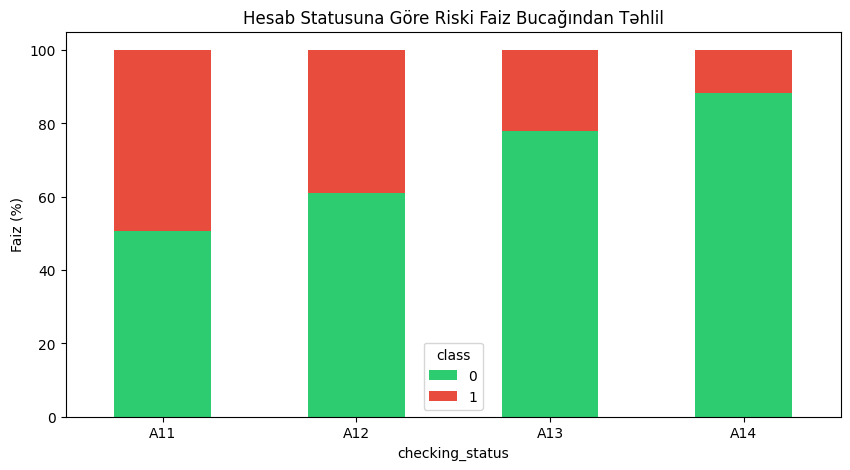

In [ ]:
checking_risk = pd.crosstab(df['checking_status'], df['class'], normalize='index') * 100

print("Cari Hesab Statusuna Göre Riskin Faizlə Paylanması:")
print(checking_risk)

checking_risk.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], figsize=(10, 5))
plt.title('Hesab Statusuna Göre Riski Faiz Bucağından Təhlil')
plt.ylabel('Faiz (%)')
plt.xticks(rotation=0)
plt.show()

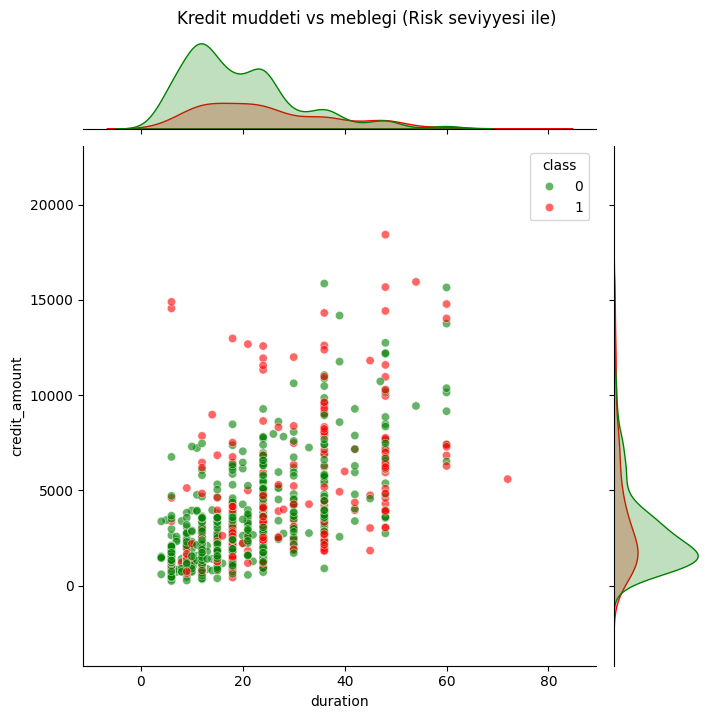

In [ ]:
sns.jointplot(
    data=df,
    x='duration',
    y='credit_amount',
    hue='class',
    palette={0: 'green', 1: 'red'},
    alpha=0.6,
    height=7
)
plt.suptitle('Kredit muddeti vs meblegi (Risk seviyyesi ile)', y=1.02)
plt.show()

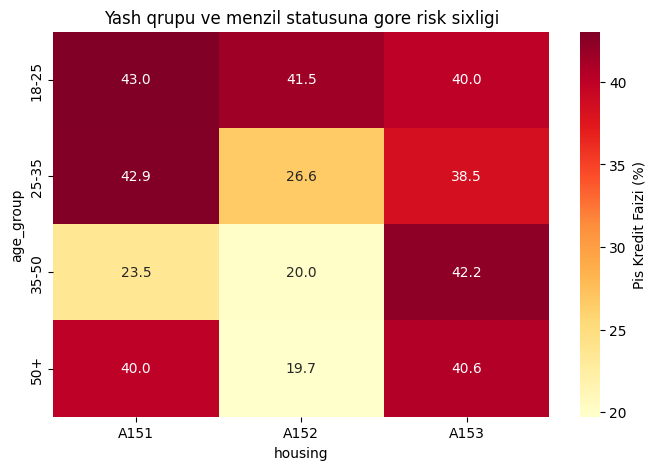

In [ ]:
df['age_group'] = pd.cut(df['age'], bins=[18, 25, 35, 50, 100], labels=['18-25', '25-35', '35-50', '50+'])
pivot_risk = df.pivot_table(index='age_group', columns='housing', values='class', aggfunc='mean') * 100
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_risk, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={'label': 'Pis Kredit Faizi (%)'})
plt.title('Yash qrupu ve menzil statusuna gore risk sixligi')
plt.show()

In [ ]:
Q1 = df['credit_amount'].quantile(0.25)
Q3 = df['credit_amount'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
outliers = df[df['credit_amount'] > upper_bound]

print(f"Kredit mebleginde ust heddi ({upper_bound} EUR) kechen autlayer mushteri sayisi: {len(outliers)}")
print(f"Autlayer mushteriler arasinda pis kredit nisbeti: {outliers['class'].mean() * 100:.1f}%")

Kredit mebleginde ust heddi (7882.375 EUR) kechen autlayer mushteri sayisi: 72
Autlayer mushteriler arasinda pis kredit nisbeti: 54.2%


In [ ]:
# Kredit tarixi (credit_history) uchun WoE ve IV hesablama numunesi
def calculate_woe_iv(dataset, feature, target):
    lst = []
    for val in dataset[feature].unique():
        all_count = len(dataset[dataset[feature] == val])
        good = len(dataset[(dataset[feature] == val) & (dataset[target] == 0)])
        bad = len(dataset[(dataset[feature] == val) & (dataset[target] == 1)])
        lst.append({'Value': val, 'All': all_count, 'Good': good, 'Bad': bad})

    df_woe = pd.DataFrame(lst)
    df_woe['Distr_Good'] = df_woe['Good'] / df_woe['Good'].sum()
    df_woe['Distr_Bad'] = df_woe['Bad'] / df_woe['Bad'].sum()
    df_woe['WoE'] = np.log(df_woe['Distr_Good'] / df_woe['Distr_Bad'])
    df_woe['IV'] = (df_woe['Distr_Good'] - df_woe['Distr_Bad']) * df_woe['WoE']

    return df_woe, df_woe['IV'].sum()

woe_df, iv_score = calculate_woe_iv(df, 'credit_history', 'class')
print(f"Credit History üçün IV balı: {iv_score:.4f}")
display(woe_df[['Value', 'Good', 'Bad', 'WoE', 'IV']])

Credit History üçün IV balı: 0.2932


,Value,Good,Bad,WoE,IV
0,A34,243,50,0.734,0.132
1,A32,361,169,-0.088,0.004
2,A33,60,28,-0.085,0.001
3,A30,15,25,-1.358,0.084
4,A31,21,28,-1.135,0.072


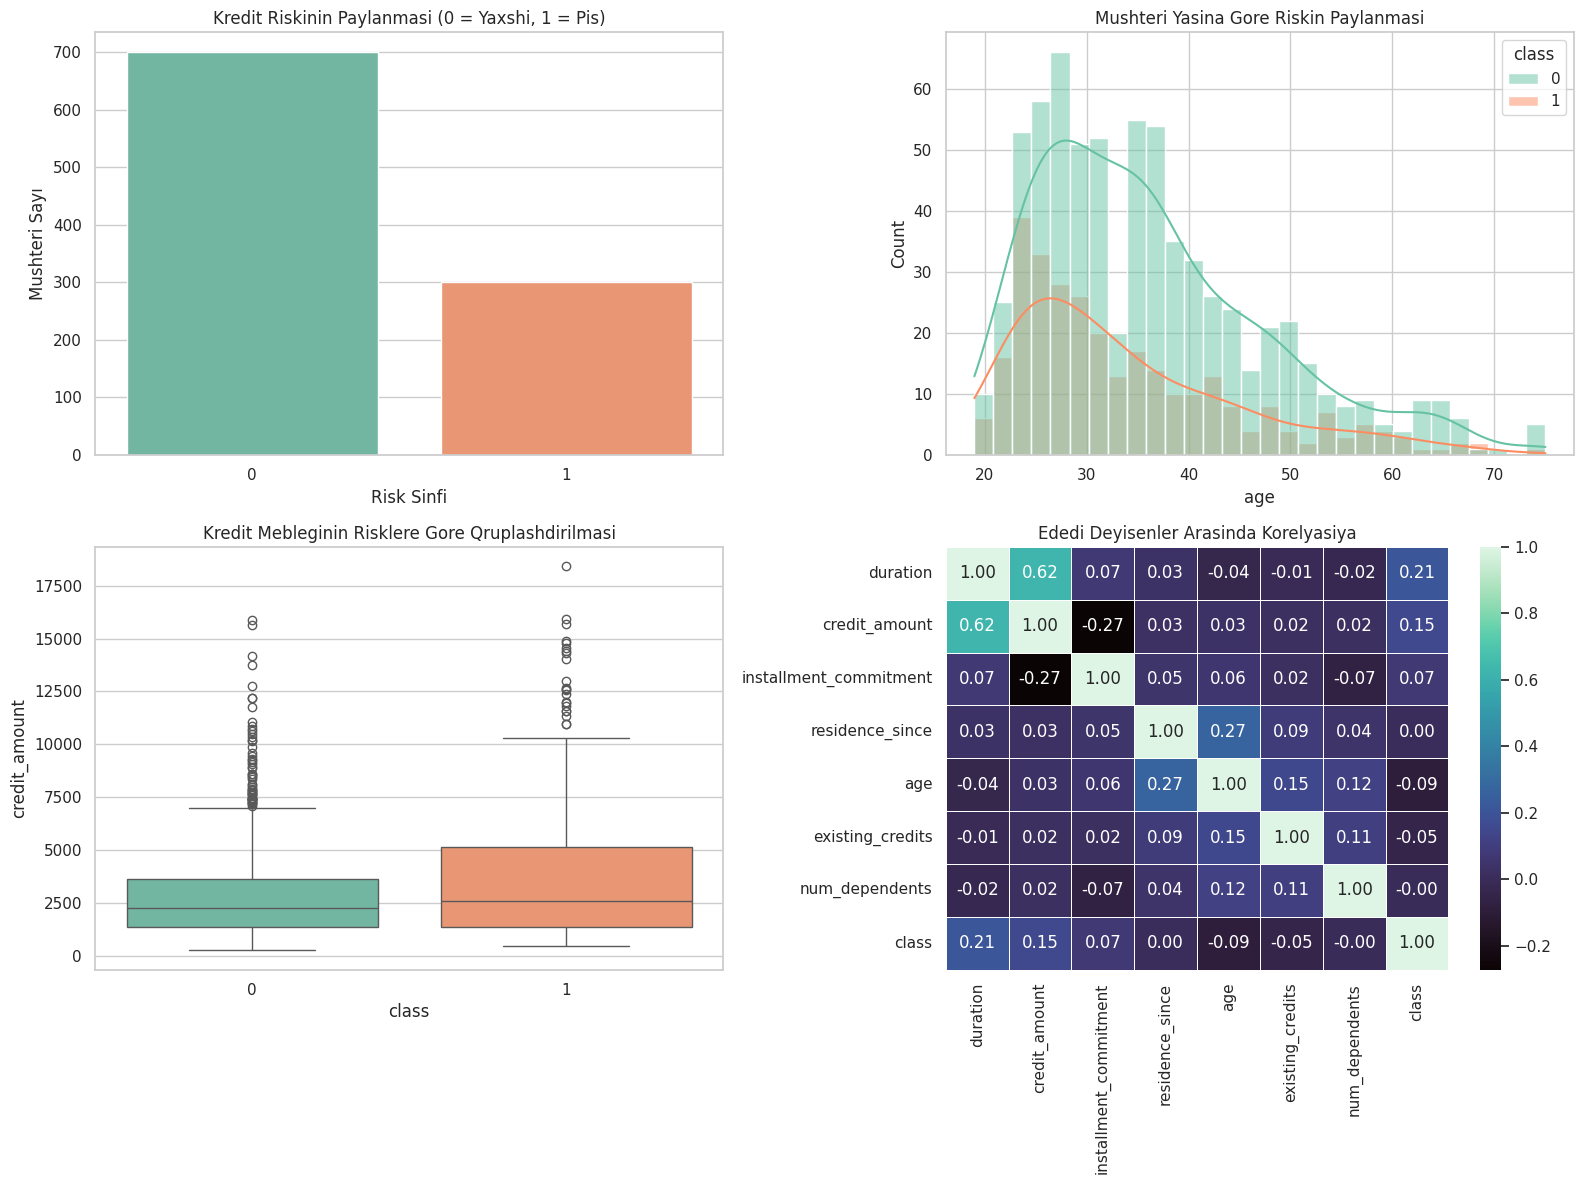

In [ ]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.countplot(data=df, x='class', palette='Set2', ax=axes[0, 0])
axes[0, 0].set_title('Kredit Riskinin Paylanmasi (0 = Yaxshi, 1 = Pis)')
axes[0, 0].set_ylabel('Mushteri Sayı')
axes[0, 0].set_xlabel('Risk Sinfi')

if 'age' in df.columns:
    sns.histplot(data=df, x='age', hue='class', kde=True, palette='Set2', bins=30, ax=axes[0, 1])
    axes[0, 1].set_title('Mushteri Yasina Gore Riskin Paylanmasi')

if 'credit_amount' in df.columns:
    sns.boxplot(data=df, x='class', y='credit_amount', palette='Set2', ax=axes[1, 0])
    axes[1, 0].set_title('Kredit Mebleginin Risklere Gore Qruplashdirilmasi')

# Redefine numeric_cols to reflect the current column names in df(AI-dan sorushdum)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='mako', fmt='.2f', linewidths=0.5, ax=axes[1, 1])
axes[1, 1].set_title('Ededi Deyisenler Arasinda Korelyasiya')

plt.tight_layout()
plt.show()

**Feature Encoding və Məlumatın Bölünməsi**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df.drop('class', axis=1)
y = df['class']

# Feature Encoding
categorical_features_for_encoding = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Apply one-hot encoding to categorical features
X_encoded = pd.get_dummies(X, columns=categorical_features_for_encoding, drop_first=True)


# Data Splitting
# stratify=y: Ensuring the same proportion of good/bad credit risk in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
# KNN, SVM ve ya Loqistik Reqressiya kimi modeller uchun xususiyyetleri eyni miqyasda olmasi vacibdir
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print(f"Train məlumatının ölçüsü: {X_train_scaled.shape}")
print(f"Test məlumatının ölçüsü: {X_test_scaled.shape}")

Train məlumatının ölçüsü: (800, 51)
Test məlumatının ölçüsü: (200, 51)


In [ ]:
# Eger y DataFrame-dirse, muvafiq sutunu seçirik
target = df['class']
# stratify=target: Hem train, Hem de test setinde eyni nisbetde Yaxshi/Pis kredit riskinin olmasini temin edir
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, target, test_size=0.2, random_state=42, stratify=target
)

**Modeling and Handling Class Imbalance**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train_scaled, y_train)

y_pred = rf_model.predict(X_test_scaled)
y_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

print("--- Random Forest Modelinin Neticeleri (Standart Threshold: 0.5) ---")
print(classification_report(y_test, y_pred, target_names=['Yaxshi (0)', 'Pis (1)']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}\n")

--- Random Forest Modelinin Neticeleri (Standart Threshold: 0.5) ---
              precision    recall  f1-score   support

  Yaxshi (0)       0.78      0.96      0.86       140
     Pis (1)       0.79      0.38      0.52        60

    accuracy                           0.79       200
   macro avg       0.79      0.67      0.69       200
weighted avg       0.79      0.79      0.76       200

ROC-AUC Score: 0.7944



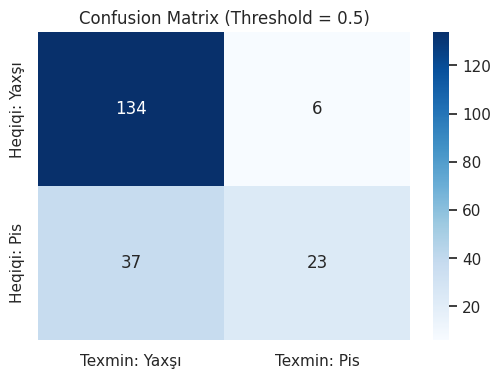

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Texmin: Yaxşı', 'Texmin: Pis'],
            yticklabels=['Heqiqi: Yaxşı', 'Heqiqi: Pis'])
plt.title('Confusion Matrix (Threshold = 0.5)')
plt.show()

**Asymmetric Cost Analysis and Threshold Optimization**

In [ ]:
from sklearn.metrics import precision_recall_curve

cost_fp = 1
cost_fn = 5

# Muxtelif ehtimallar uchun threshold-lari chixaririq
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

min_cost = float('inf')
best_threshold = 0.5

for threshold in thresholds:
    y_pred_custom = (y_pred_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_custom).ravel()

    current_cost = (fp * cost_fp) + (fn * cost_fn)

    if current_cost < min_cost:
        min_cost = current_cost
        best_threshold = threshold

print(f"Tapilmish en Optimal qerar Serhedi (Threshold): {best_threshold:.4f}")
print(f"Bu serhed ile bank uchun minimum ehtimal olunan zerer (Cost): {min_cost}")

Tapilmish en Optimal qerar Serhedi (Threshold): 0.2500
Bu serhed ile bank uchun minimum ehtimal olunan zerer (Cost): 104


In [ ]:
y_pred_optimal = (y_pred_proba >= best_threshold).astype(int)

print("\n--- Optimal Threshold ile Neticeler ---")
print(classification_report(y_test, y_pred_optimal, target_names=['Yaxshi (0)', 'Pis (1)']))


--- Optimal Threshold ile Neticeler ---
              precision    recall  f1-score   support

  Yaxshi (0)       0.90      0.54      0.68       140
     Pis (1)       0.45      0.87      0.59        60

    accuracy                           0.64       200
   macro avg       0.68      0.70      0.63       200
weighted avg       0.77      0.64      0.65       200



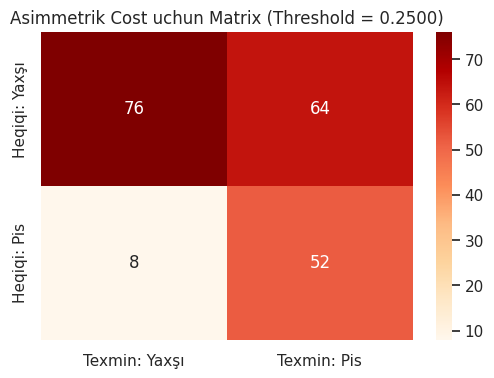

In [ ]:
cm_opt = confusion_matrix(y_test, y_pred_optimal)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='OrRd',
            xticklabels=['Texmin: Yaxşı', 'Texmin: Pis'],
            yticklabels=['Heqiqi: Yaxşı', 'Heqiqi: Pis'])
plt.title(f'Asimmetrik Cost uchun Matrix (Threshold = {best_threshold:.4f})')
plt.show()

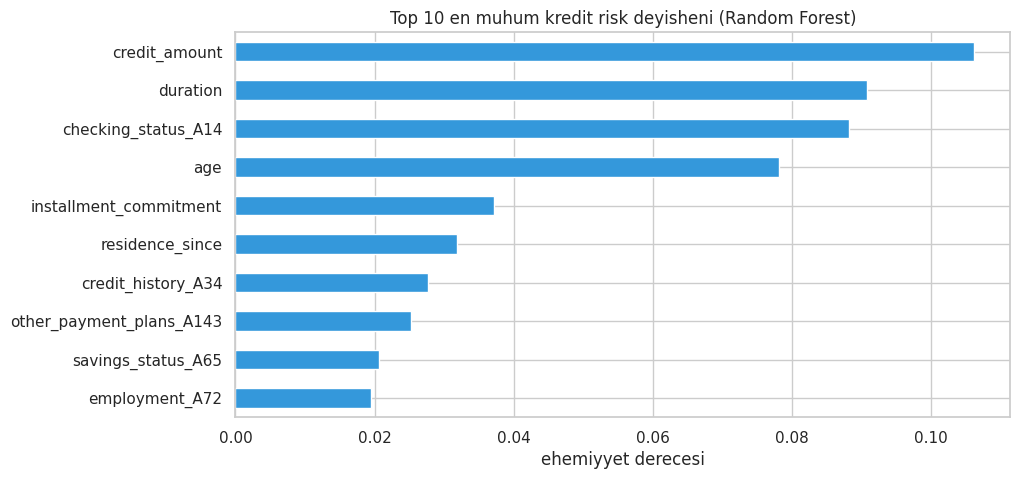

In [ ]:
import shap
import matplotlib.pyplot as plt

importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
top_features.plot(kind='barh', color='#3498db')
plt.title('Top 10 en muhum kredit risk deyisheni (Random Forest)')
plt.xlabel('ehemiyyet derecesi')
plt.gca().invert_yaxis()
plt.show()

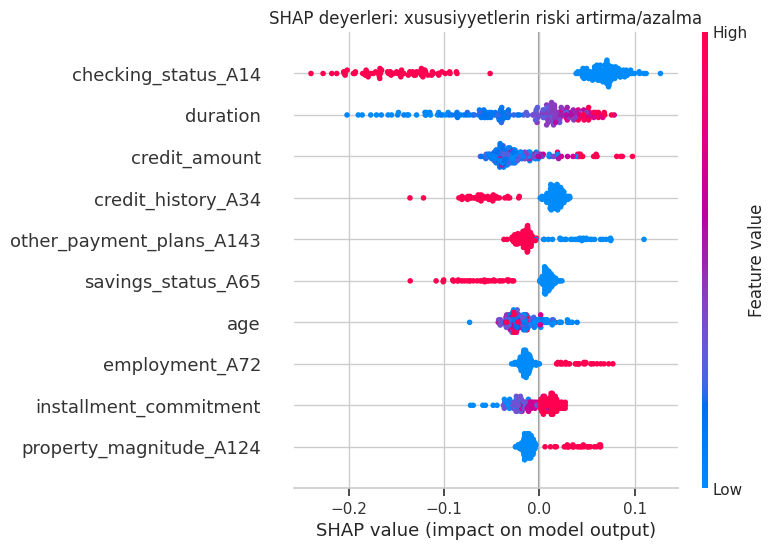

In [38]:
# Agac modelleri uchun TreeExplainer istifade olunur
explainer = shap.TreeExplainer(rf_model)
# X_test_scaled.values istifade ederek SHAP deyerlerini hesablayin
shap_values = explainer.shap_values(X_test_scaled.values)

# SHAP Summary Plot (Deyishenlerin riske musbet/menfi tesirini gosterir)
# Class 1 (Pis kredit) uzre tesirleri
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values[:, :, 1], # Class 1 ucun SHAP deyerleri (dogru dilimleme)
    X_test_scaled.values, # Original scaled feature values (numpy array kimi)
    feature_names=X_test_scaled.columns, # DataFrame-den sütun adlarını teqdim edin
    max_display=10,
    show=False
)
plt.title("SHAP deyerleri: xususiyyetlerin riski artirma/azalma", fontsize=12)
plt.show()

#Burada sehvlik elemishdim ve SI istifade eledim